# 04 — LUNA16 ResNet50 (ImageNet pretrained)

5-fold CV on the 2D axial slices. Class imbalance handled via `pos_weight` in `BCEWithLogitsLoss`, then Youden's J threshold calibration per fold.

Pairs with notebook 05 (random init) for the transfer learning ablation.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
import yaml
from torchvision import transforms

from utils.seed import set_seed
from utils.models import build_resnet50
from utils.training import train_dl_cv, save_fold_results
from utils.metrics import aggregate_folds
from utils.stats import format_results_table

with open('../configs/luna16.yaml') as f:
    cfg = yaml.safe_load(f)
set_seed(cfg['seed'])

In [2]:
cache_dir = Path('..') / cfg['data']['cache_dir']
slices = np.load(cache_dir / 'slices_2d.npy')   # (N, H, W), float32 in [0,1]
labels = pd.read_csv(cache_dir / 'labels.csv')['label'].to_numpy().astype(int)
print('slices', slices.shape, 'pos rate:', labels.mean())

from utils.data_luna16 import SlicesDataset
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
])
eval_tf = None

dataset = SlicesDataset(slices, labels, transform=eval_tf)

slices (124, 224, 224) pos rate: 0.9032258064516129


In [3]:
def model_fn():
    return build_resnet50(pretrained=True, num_classes=1)

results_dir = Path('..') / cfg['paths']['results']
results_dir.mkdir(parents=True, exist_ok=True)

folds = train_dl_cv(
    dataset=dataset,
    model_fn=model_fn,
    labels=labels,
    n_splits=cfg['cv']['n_splits'],
    seed=cfg['seed'],
    epochs=cfg['dl']['epochs'],
    batch_size=cfg['dl']['batch_size'],
    lr=cfg['dl']['lr'],
    weight_decay=cfg['dl']['weight_decay'],
    patience=cfg['dl']['patience'],
    num_workers=cfg['dl']['num_workers'],
    device='auto',
    augment_train=train_tf,
    augment_eval=eval_tf,
    verbose=True,
)

save_fold_results(folds, results_dir / 'luna16_ResNet50_pretrained.json')
agg = aggregate_folds([f.metrics_calibrated for f in folds])
format_results_table({'ResNet50_pretrained': agg})

[fold 0] train=99 test=25 pos_train=89 pos_test=23
  epoch  1/50 loss=0.1410 val_auc=0.5217
  epoch  2/50 loss=0.1261 val_auc=0.5217
  epoch  3/50 loss=0.1215 val_auc=0.5000
  epoch  4/50 loss=0.1188 val_auc=0.5435
  epoch  5/50 loss=0.1221 val_auc=0.5435
  epoch  6/50 loss=0.1038 val_auc=0.5435
  epoch  7/50 loss=0.1020 val_auc=0.5435
  epoch  8/50 loss=0.0895 val_auc=0.6087
  epoch  9/50 loss=0.0797 val_auc=0.5652
  epoch 10/50 loss=0.0779 val_auc=0.5652
  epoch 11/50 loss=0.0658 val_auc=0.5217
  epoch 12/50 loss=0.0621 val_auc=0.4565
  epoch 13/50 loss=0.0499 val_auc=0.5000
  epoch 14/50 loss=0.0408 val_auc=0.5000
  epoch 15/50 loss=0.0359 val_auc=0.4783
  early stop at epoch 15 (patience=7)
[fold 0] AUC=0.6087 thr=0.477 BalAcc(cal)=0.750
[fold 1] train=99 test=25 pos_train=89 pos_test=23
  epoch  1/50 loss=0.1414 val_auc=0.3261
  epoch  2/50 loss=0.1321 val_auc=0.3478
  epoch  3/50 loss=0.1254 val_auc=0.4348
  epoch  4/50 loss=0.1157 val_auc=0.4348
  epoch  5/50 loss=0.1006 val_auc

,accuracy,sensitivity,specificity,precision,f1,balanced_accuracy,auc_roc,pr_auc
model,,,,,,,,
ResNet50_pretrained,0.806 ± 0.115,0.874 ± 0.104,0.200 ± 0.274,0.906 ± 0.050,0.888 ± 0.072,0.537 ± 0.161,0.598 ± 0.129,0.942 ± 0.032


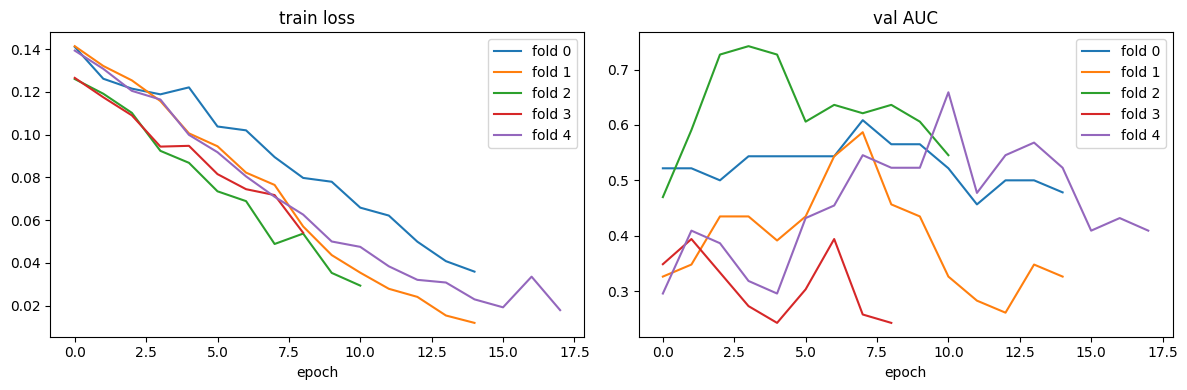

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for f in folds:
    if f.train_history is None:
        continue
    axes[0].plot(f.train_history['loss'], label=f'fold {f.fold}')
    axes[1].plot(f.train_history['auc'], label=f'fold {f.fold}')
axes[0].set_title('train loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].set_title('val AUC'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()